<a href="https://colab.research.google.com/github/mallugze/Business-prediction-ml-model/blob/main/finally.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---------- Checking for existing trained model ----------
✅ Loaded existing model with 26 feature columns.

---------- Upload your NEW dataset (CSV to predict or retrain) ----------


Saving good data.csv to good data (2).csv
Uploaded new file: good data (2).csv


,UnitCost,UnitPrice,Discount,UnitsSold,StoreType,CustomerRating,ProfitMargin,Revenue,IsTopSeller,ProductCategory_Kurti,...,Brand_FabIndia,Brand_GlobalDesi,Brand_H&M,Brand_Zara,Region_North,Region_South,Region_West,Season_Spring,Season_Summer,Season_Winter
0,-0.987230,1.006539,0.17,0.254343,0,3.0,5.81000,0.889313,1,False,...,False,False,False,True,True,False,False,True,False,False
1,-1.206922,-0.238978,0.17,-0.176818,0,4.9,4.30000,-0.272157,0,False,...,False,False,False,True,False,False,False,False,True,False
2,0.992120,1.599548,0.03,-1.354467,1,2.9,1.45000,-0.789794,0,False,...,False,False,False,True,False,False,True,True,False,False
3,-1.286393,1.223982,0.10,0.614717,0,3.9,7.22625,1.700880,1,False,...,False,False,False,True,False,False,True,False,True,False
4,1.563602,-1.754766,0.08,-0.376310,0,3.9,-0.90000,-1.104325,0,False,...,False,False,True,False,True,False,False,False,False,False


✅ Column structure matches existing model.

✅ Predictions saved to Predicted_Results.csv

📊 Evaluation Metrics:
 MAE = 0.101
 R2  = 0.935


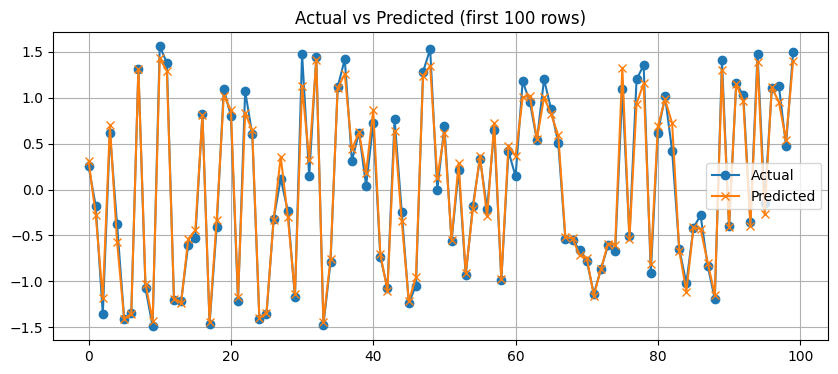

In [ ]:
*# ==============================================
# SMART SELF-UPDATING SALES PREDICTION MODEL
# ==============================================

import os, io, pickle, pandas as pd, numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

def dprint(msg):
    print("\n" + "-"*10 + f" {msg} " + "-"*10)

# ----------------------------------------------
# 1) Load or Train Initial Model
# ----------------------------------------------
dprint("Checking for existing trained model")
model, X_cols = None, None

if os.path.exists("sales_random_forest_model.pkl"):
    with open("sales_random_forest_model.pkl", "rb") as f:
        model, X_cols = pickle.load(f)
    print("✅ Loaded existing model with", len(X_cols), "feature columns.")
else:
    print("❌ No model found. Please upload your training data (CSV).")
    uploaded = files.upload()
    train_filename = list(uploaded.keys())[0]
    train_df = pd.read_csv(io.BytesIO(uploaded[train_filename]))
    print("Training data uploaded:", train_filename)

    # Drop unwanted columns
    train_df = train_df.drop(columns=['index','Product','Productid','OrderId','SaleDate','Store'], errors='ignore')

    # Identify target column
    target_candidates = ['Units_Sold','UnitsSold','Units Sold']
    target_col = next((c for c in train_df.columns if c in target_candidates), train_df.columns[-1])

    # One-hot encode categorical
    cat_cols = train_df.select_dtypes(include=['object','category']).columns.tolist()
    if target_col in cat_cols: cat_cols.remove(target_col)
    train_df = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)

    train_df = train_df.dropna(subset=[target_col]).dropna()
    X = train_df.drop(columns=[target_col])
    y = train_df[target_col]
    X = X.apply(lambda col: pd.to_numeric(col, errors='coerce')).fillna(0)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    X_cols = list(X.columns)

    # Save model
    with open("sales_random_forest_model.pkl", "wb") as f:
        pickle.dump((model, X_cols), f)
    print("✅ Model trained and saved!")

# ----------------------------------------------
# 2) Upload new dataset for prediction or retraining
# ----------------------------------------------
dprint("Upload your NEW dataset (CSV to predict or retrain)")
uploaded2 = files.upload()
new_filename = list(uploaded2.keys())[0]
new_df = pd.read_csv(io.BytesIO(uploaded2[new_filename]))
print("Uploaded new file:", new_filename)
display(new_df.head())

# Clean new data
new_df = new_df.drop(columns=['Productid','OrderId','SaleDate','Store','Predicted_Units_Sold'], errors='ignore')

# Detect target if present
actual_col = None
for candidate in ['UnitsSold','Units_Sold','Units Sold']:
    if candidate in new_df.columns:
        actual_col = candidate
        break

if actual_col:
    y_new_actual = new_df[actual_col].copy()
    new_df = new_df.drop(columns=[actual_col])

# Encode categorical
cat_cols_new = new_df.select_dtypes(include=['object','category']).columns.tolist()
new_df = pd.get_dummies(new_df, columns=cat_cols_new, drop_first=True)

# ----------------------------------------------
# 3) Check for unseen/new columns → retrain if needed
# ----------------------------------------------
if set(new_df.columns) != set(X_cols):
    dprint("Column mismatch detected! Retraining model with combined data...")
    combined_cols = list(set(new_df.columns).union(set(X_cols)))

    # Add missing columns as 0
    def align(df):
        for c in combined_cols:
            if c not in df.columns:
                df[c] = 0
        return df[combined_cols]

    # Rebuild train_df for retrain
    retrain_df = new_df.copy()
    if actual_col:
        retrain_df[actual_col] = y_new_actual
    retrain_df = retrain_df.dropna()

    # Split again
    X_new = align(retrain_df.drop(columns=[actual_col])) if actual_col else align(new_df)
    y_new = retrain_df[actual_col] if actual_col else None

    if y_new is not None:
        model.fit(X_new, y_new)
        X_cols = combined_cols
        with open("sales_random_forest_model.pkl", "wb") as f:
            pickle.dump((model, X_cols), f)
        print("🔁 Model retrained and updated with new structure!")
else:
    print("✅ Column structure matches existing model.")

# ----------------------------------------------
# 4) Prepare for prediction
# ----------------------------------------------
for c in X_cols:
    if c not in new_df.columns:
        new_df[c] = 0
new_df = new_df[X_cols]
new_df = new_df.apply(lambda col: pd.to_numeric(col, errors='coerce')).fillna(0)

# ----------------------------------------------
# 5) Predict
# ----------------------------------------------
preds = model.predict(new_df)
new_df['Predicted_Units_Sold'] = preds

# Attach predictions
result = new_df.copy()
if actual_col:
    result['Actual_Units_Sold'] = y_new_actual.values

# Save result
result.to_csv("Predicted_Results.csv", index=False)
print("\n✅ Predictions saved to Predicted_Results.csv")

# ----------------------------------------------
# 6) Evaluate if ground truth exists
# ----------------------------------------------
if actual_col:
    mae = mean_absolute_error(result['Actual_Units_Sold'], result['Predicted_Units_Sold'])
    r2 = r2_score(result['Actual_Units_Sold'], result['Predicted_Units_Sold'])
    print("\n📊 Evaluation Metrics:")
    print(" MAE =", round(mae,3))
    print(" R2  =", round(r2,3))

# ----------------------------------------------
# 7) Plot
# ----------------------------------------------
plt.figure(figsize=(10,4))
nplot = min(100, len(result))
if actual_col:
    plt.plot(result['Actual_Units_Sold'].values[:nplot], label='Actual', marker='o')
plt.plot(result['Predicted_Units_Sold'].values[:nplot], label='Predicted', marker='x')
plt.legend()
plt.title("Actual vs Predicted (first 100 rows)")
plt.grid(True)
plt.show()



Saving good data.csv to good data (3).csv
✅ Loaded good data (3).csv with 500 rows and 27 columns

🏆 Average performance by brand:



,Discount,CustomerRating,ProfitMargin,Revenue,UnitsSold
Brand,,,,,
Zara,0.145625,3.683750,1.888500,0.016111,0.161434
FabIndia,0.160189,3.781132,1.932264,0.079520,0.014114
GlobalDesi,0.139223,3.652427,1.711299,-0.064833,-0.041256
H&M,0.132430,3.664486,2.292874,0.002854,-0.058473


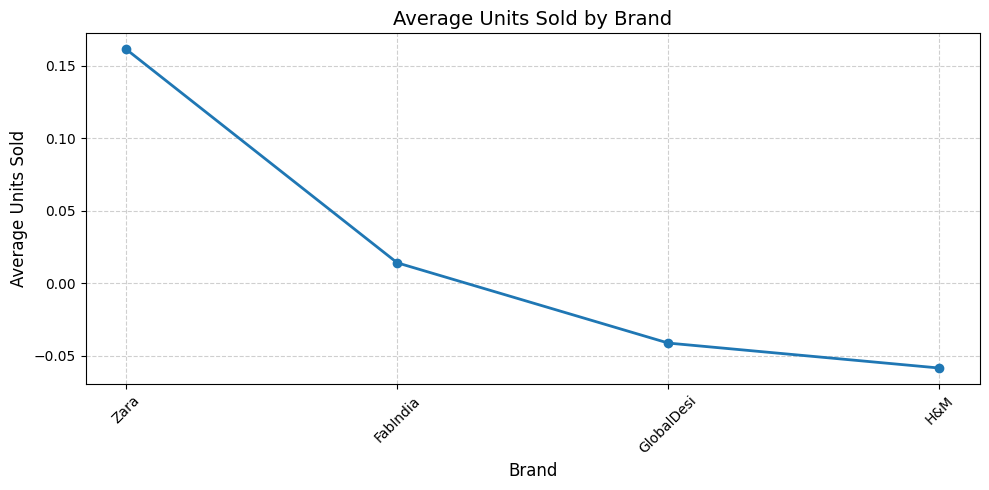


💬 Insight:
🏅 Top brand: **Zara**
📈 Reason: It had better customer ratings, generated higher revenue and had overall higher sales.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# === Step 1: Upload your dataset ===
uploaded = files.upload()
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print(f"✅ Loaded {filename} with {len(data)} rows and {len(data.columns)} columns\n")

# === Step 2: Identify encoded columns dynamically ===
brand_cols = [c for c in data.columns if c.startswith("Brand_")]
category_cols = [c for c in data.columns if c.startswith("ProductCategory_")]
season_cols = [c for c in data.columns if c.startswith("Season_")]
region_cols = [c for c in data.columns if c.startswith("Region_")]

# === Step 3: Define useful numeric features ===
features = ["Discount", "CustomerRating", "ProfitMargin", "Revenue", "UnitsSold"]
features = [f for f in features if f in data.columns]

# === Step 4: Decode one-hot labels ===
def extract_label(row, prefix_list):
    for col in prefix_list:
        if col in row and row[col] == 1:
            return col.split("_", 1)[-1]
    return None

data["Brand"] = data.apply(lambda r: extract_label(r, brand_cols), axis=1)
data["Category"] = data.apply(lambda r: extract_label(r, category_cols), axis=1)
data["Season"] = data.apply(lambda r: extract_label(r, season_cols), axis=1)
data["Region"] = data.apply(lambda r: extract_label(r, region_cols), axis=1)

# === Step 5: Group by brand ===
brand_summary = data.groupby("Brand")[features].mean().sort_values(by="UnitsSold", ascending=False)

print("🏆 Average performance by brand:\n")
display(brand_summary)

# === Step 6: Line chart (like actual vs predicted style) ===
plt.figure(figsize=(10,5))
plt.plot(brand_summary.index, brand_summary["UnitsSold"], marker='o', linestyle='-', linewidth=2)
plt.title("Average Units Sold by Brand", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Average Units Sold", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Step 7: Explain top performer ===
top_brand = brand_summary.index[0]
top_row = brand_summary.loc[top_brand]

reason_parts = []
if "Discount" in top_row and top_row["Discount"] > data["Discount"].mean():
    reason_parts.append("offered higher discounts")
if "CustomerRating" in top_row and top_row["CustomerRating"] > data["CustomerRating"].mean():
    reason_parts.append("had better customer ratings")
if "ProfitMargin" in top_row and top_row["ProfitMargin"] > data["ProfitMargin"].mean():
    reason_parts.append("maintained higher profit margins")
if "Revenue" in top_row and top_row["Revenue"] > data["Revenue"].mean():
    reason_parts.append("generated higher revenue")
if "UnitsSold" in top_row and top_row["UnitsSold"] > data["UnitsSold"].mean():
    reason_parts.append("had overall higher sales")

reason_text = (
    ", ".join(reason_parts[:-1]) + " and " + reason_parts[-1]
    if len(reason_parts) > 1
    else (reason_parts[0] if reason_parts else "performed consistently well")
)

print(f"\n💬 Insight:")
print(f"🏅 Top brand: **{top_brand}**")
print(f"📈 Reason: It {reason_text}.")
